In [9]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Define color scheme
COLORS = {
    'optimized-cuda': '#27AE60',     # Green
    'sparse-cuda': '#8E44AD',        # Purple
    'naive-cuda-mpi': '#95A5A6',     # Gray
    'optimized-cuda-mpi': '#F39C12', # Orange
    'L1': '#3498DB',
    'L2': '#E74C3C',
    'DRAM': '#2C3E50'
}

print("✓ Libraries imported and matplotlib configured")

✓ Libraries imported and matplotlib configured


In [10]:
# Configuration
TIMESTAMP = "20260106_190353"  # Update this to the desired timestamp
BASE_PATH = Path(f"results/ncu/{TIMESTAMP}")

# Implementations to analyze
# Note: Add MPI implementations here if available
IMPLEMENTATIONS = [
    "optimized-cuda", 
    "sparse-cuda",
    "optimized-cuda-mpi", 
    "naive-cuda-mpi"
]

# Metric mapping for readable labels
METRIC_MAP = {
    'dram__bytes_read.sum': 'DRAM Read',
    'dram__bytes_write.sum': 'DRAM Write',
    'lts__t_sectors_lookup_hit.sum': 'L2 Hit (Sectors)',
    'lts__t_sectors_lookup_miss.sum': 'L2 Miss (Sectors)',
    'l1tex__t_bytes_lookup_hit.sum': 'L1 Hit (Bytes)',
    'l1tex__t_bytes_lookup_miss.sum': 'L1 Miss (Bytes)',
    'smsp__average_warps_issue_stalled_barrier_per_issue_active.pct': 'Stall: Barrier',
    'smsp__warp_issue_stalled_long_scoreboard_per_warp_active.pct': 'Stall: Long Scoreboard',
    'smsp__warp_issue_stalled_short_scoreboard_per_warp_active.pct': 'Stall: Short Scoreboard',
    'smsp__warp_issue_stalled_wait_per_warp_active.pct': 'Stall: Wait',
    'smsp__warp_issue_stalled_mio_throttle_per_warp_active.pct': 'Stall: MIO Throttle',
    'smsp__warp_issue_stalled_membar_per_warp_active.pct': 'Stall: Membar',
    'sm__sass_branch_targets.avg': 'Branches',
    'sm__sass_branch_targets_threads_divergent.sum': 'Divergent Branches',
    'gpu__time_duration.sum': 'Duration'
}

def load_ncu_csv(impl_name):
    """Load NCU CSV file for a given implementation."""
    file_path = BASE_PATH / impl_name / "snp_profile_metrics.csv"
    if not file_path.exists():
        print(f"⚠ Warning: File not found for {impl_name}: {file_path}")
        return None
    
    try:
        # Read CSV, skipping the units row (row 2, index 1)
        # We read header=0 to get column names, then drop index 0 (which is the units row)
        df = pd.read_csv(file_path, header=0)
        
        # The second row (index 0) contains units like 'Mbyte', 'us', etc.
        # We can store them if needed, but for now we'll just drop the row
        units = df.iloc[0]
        df = df.drop(0).reset_index(drop=True)
        
        # Convert numeric columns
        for col in df.columns:
            if col not in ['ID', 'Process ID', 'Process Name', 'Host Name', 'Kernel Name', 'Context', 'Stream', 'Block Size', 'Grid Size', 'Device', 'CC']:
                df[col] = pd.to_numeric(df[col], errors='coerce')
                
        df['Implementation'] = impl_name
        return df
    except Exception as e:
        print(f"Error loading {impl_name}: {e}")
        return None

print(f"✓ Configuration defined. Base path: {BASE_PATH}")

✓ Configuration defined. Base path: results/ncu/20260106_190353


In [11]:
# Load Data
dfs = []
for impl in IMPLEMENTATIONS:
    df = load_ncu_csv(impl)
    if df is not None:
        dfs.append(df)

if not dfs:
    raise ValueError("No data loaded! Check paths and timestamps.")

full_df = pd.concat(dfs, ignore_index=True)

# Preprocessing
# Simplify Kernel Names
def simplify_kernel_name(name):
    if 'neuronDynamicsKernel' in name:
        return 'Neuron Dynamics'
    elif 'synapseTransferKernel' in name:
        return 'Synapse Transfer'
    elif 'k_step_compressed' in name:
        return 'Step Compressed'
    elif 'k_calc_spiking_vector' in name:
        return 'Calc Spiking Vector'
    elif 'k_update_delays' in name:
        return 'Update Delays'
    else:
        # Fallback: take the function name before arguments
        return name.split('(')[0].split('::')[-1][:20]

full_df['Kernel Label'] = full_df['Kernel Name'].apply(simplify_kernel_name)

# Filter for main kernels only (optional, but keeps charts clean)
# We'll keep all for now but group by Label
grouped_df = full_df.groupby(['Implementation', 'Kernel Label']).mean(numeric_only=True).reset_index()

print(f"✓ Loaded data for {len(dfs)} implementations.")
print("Kernels found:", full_df['Kernel Label'].unique())
grouped_df.head()

⚠ Warning: File not found for optimized-cuda-mpi: results/ncu/20260106_190353/optimized-cuda-mpi/snp_profile_metrics.csv
⚠ Warning: File not found for naive-cuda-mpi: results/ncu/20260106_190353/naive-cuda-mpi/snp_profile_metrics.csv
✓ Loaded data for 2 implementations.
Kernels found: ['Neuron Dynamics' 'Synapse Transfer' 'Update Delays'
 'Calc Spiking Vector' 'Step Compressed']


,Implementation,Kernel Label,ID,Process ID,Context,Stream,Device,CC,dram__bytes_read.sum,dram__bytes_write.sum,...,lts__t_sectors_lookup_hit.sum,lts__t_sectors_lookup_miss.sum,sm__sass_branch_targets.avg,sm__sass_branch_targets_threads_divergent.sum,smsp__average_warps_issue_stalled_barrier_per_issue_active.pct,smsp__warp_issue_stalled_long_scoreboard_per_warp_active.pct,smsp__warp_issue_stalled_membar_per_warp_active.pct,smsp__warp_issue_stalled_mio_throttle_per_warp_active.pct,smsp__warp_issue_stalled_short_scoreboard_per_warp_active.pct,smsp__warp_issue_stalled_wait_per_warp_active.pct
0,optimized-cuda,Neuron Dynamics,2.0,1595351.0,1.0,7.0,0.0,7.5,11.833131,0.555221,...,1.057263e+05,1.901963e+05,2205.383333,1.0,0.0,70.246454,0.0,0.000065,0.578792,10.457208
1,optimized-cuda,Synapse Transfer,3.0,1595351.0,1.0,7.0,0.0,7.5,68.812832,1.400747,...,5.365540e+05,1.835754e+06,0.000000,0.0,0.0,80.548036,0.0,0.041237,2.524502,8.666600
2,sparse-cuda,Calc Spiking Vector,4.0,1596134.0,1.0,7.0,0.0,7.5,11.254176,0.509813,...,8.953333e+04,1.808703e+05,2190.425000,1.0,0.0,61.540420,0.0,0.000000,0.737089,15.095395
3,sparse-cuda,Step Compressed,5.0,1596134.0,1.0,7.0,0.0,7.5,61.357472,1.500395,...,4.412796e+06,1.413557e+06,8774.933333,0.0,0.0,88.316620,0.0,0.000000,0.002312,8.222625
4,sparse-cuda,Update Delays,3.0,1596134.0,1.0,7.0,0.0,7.5,0.032416,0.000000,...,5.606667e+02,7.790000e+02,0.000000,0.0,0.0,35.209000,0.0,0.000000,2.437753,7.039258


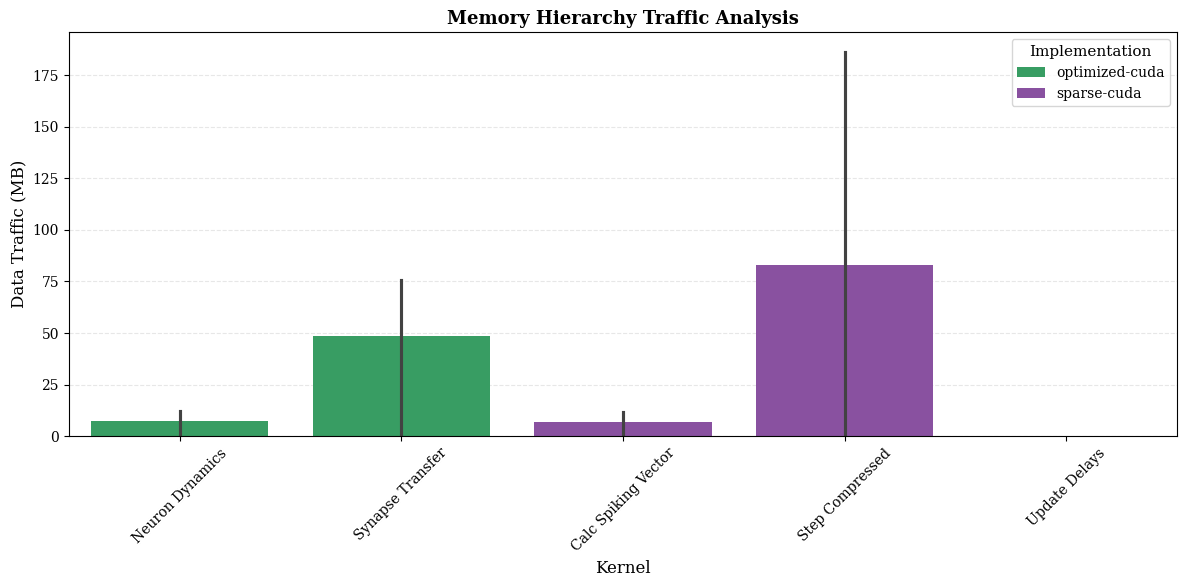

In [12]:
# Visualization: Memory Hierarchy Traffic
# Compare Global Memory vs L2 vs L1 traffic

# Prepare data for plotting
mem_metrics = ['dram__bytes_read.sum', 'dram__bytes_write.sum', 
               'lts__t_sectors_lookup_hit.sum', 'lts__t_sectors_lookup_miss.sum',
               'l1tex__t_bytes_lookup_hit.sum', 'l1tex__t_bytes_lookup_miss.sum']

# Calculate total bytes for L2 (sectors * 32 bytes)
# Note: L2 sector size is typically 32 bytes
grouped_df['L2 Traffic (MB)'] = (grouped_df['lts__t_sectors_lookup_hit.sum'] + grouped_df['lts__t_sectors_lookup_miss.sum']) * 32 / 1e6
grouped_df['L1 Traffic (MB)'] = (grouped_df['l1tex__t_bytes_lookup_hit.sum'] + grouped_df['l1tex__t_bytes_lookup_miss.sum']) / 1e6
grouped_df['DRAM Traffic (MB)'] = (grouped_df['dram__bytes_read.sum'] + grouped_df['dram__bytes_write.sum']) # Already in MB based on units row, but let's verify. 
# Wait, the units row said 'Mbyte' for dram, but 'sector' for lts, and 'Mbyte' for l1tex?
# Let's check the units row from the file content I read earlier.
# dram: Mbyte
# l1tex: Mbyte
# lts: sector
# So DRAM and L1 are already in MB. L2 needs conversion.

# Create plot
fig, ax = plt.subplots(figsize=(12, 6))

# Melt for seaborn
mem_plot_df = grouped_df.melt(id_vars=['Implementation', 'Kernel Label'], 
                              value_vars=['DRAM Traffic (MB)', 'L2 Traffic (MB)', 'L1 Traffic (MB)'],
                              var_name='Memory Level', value_name='Traffic (MB)')

sns.barplot(data=mem_plot_df, x='Kernel Label', y='Traffic (MB)', hue='Implementation', 
            palette=[COLORS.get(i, '#333') for i in grouped_df['Implementation'].unique()], ax=ax)

ax.set_title('Memory Hierarchy Traffic Analysis')
ax.set_ylabel('Data Traffic (MB)')
ax.set_xlabel('Kernel')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

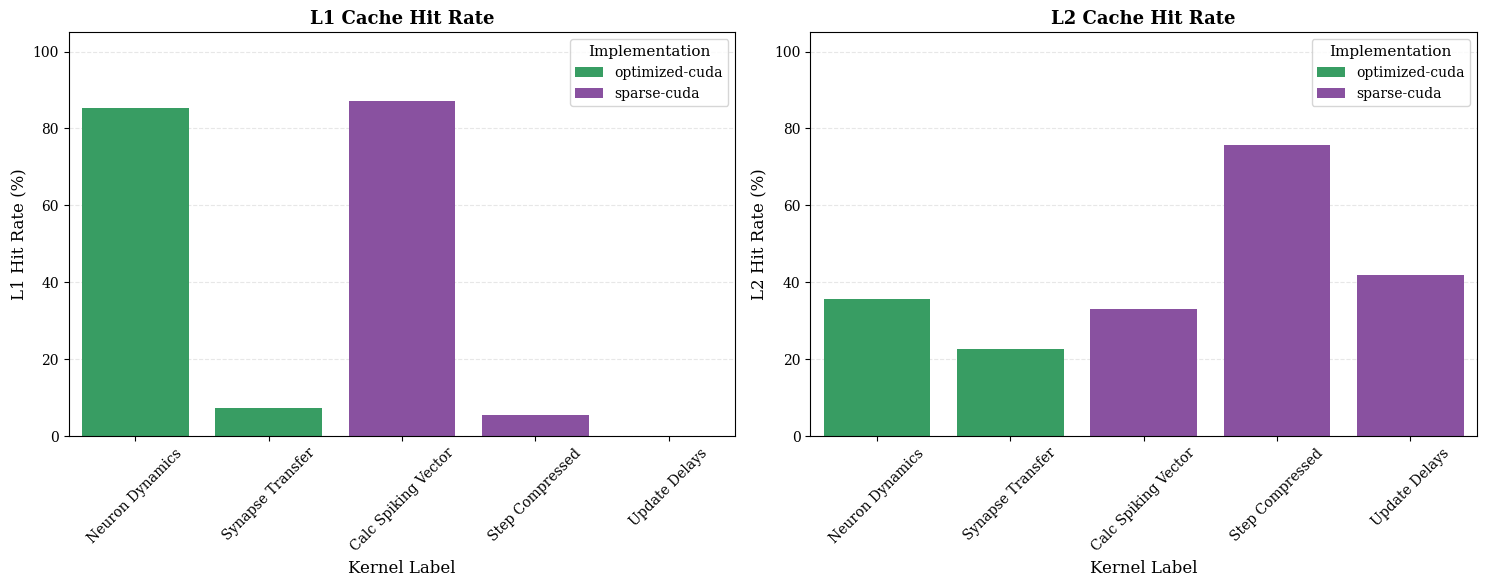

In [13]:
# Visualization: Cache Hit Rates
# Calculate Hit Rates
grouped_df['L1 Hit Rate (%)'] = grouped_df['l1tex__t_bytes_lookup_hit.sum'] / (grouped_df['l1tex__t_bytes_lookup_hit.sum'] + grouped_df['l1tex__t_bytes_lookup_miss.sum']) * 100
grouped_df['L2 Hit Rate (%)'] = grouped_df['lts__t_sectors_lookup_hit.sum'] / (grouped_df['lts__t_sectors_lookup_hit.sum'] + grouped_df['lts__t_sectors_lookup_miss.sum']) * 100

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=grouped_df, x='Kernel Label', y='L1 Hit Rate (%)', hue='Implementation',
            palette=[COLORS.get(i, '#333') for i in grouped_df['Implementation'].unique()], ax=ax1)
ax1.set_title('L1 Cache Hit Rate')
ax1.set_ylim(0, 105)
ax1.tick_params(axis='x', rotation=45)

sns.barplot(data=grouped_df, x='Kernel Label', y='L2 Hit Rate (%)', hue='Implementation',
            palette=[COLORS.get(i, '#333') for i in grouped_df['Implementation'].unique()], ax=ax2)
ax2.set_title('L2 Cache Hit Rate')
ax2.set_ylim(0, 105)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

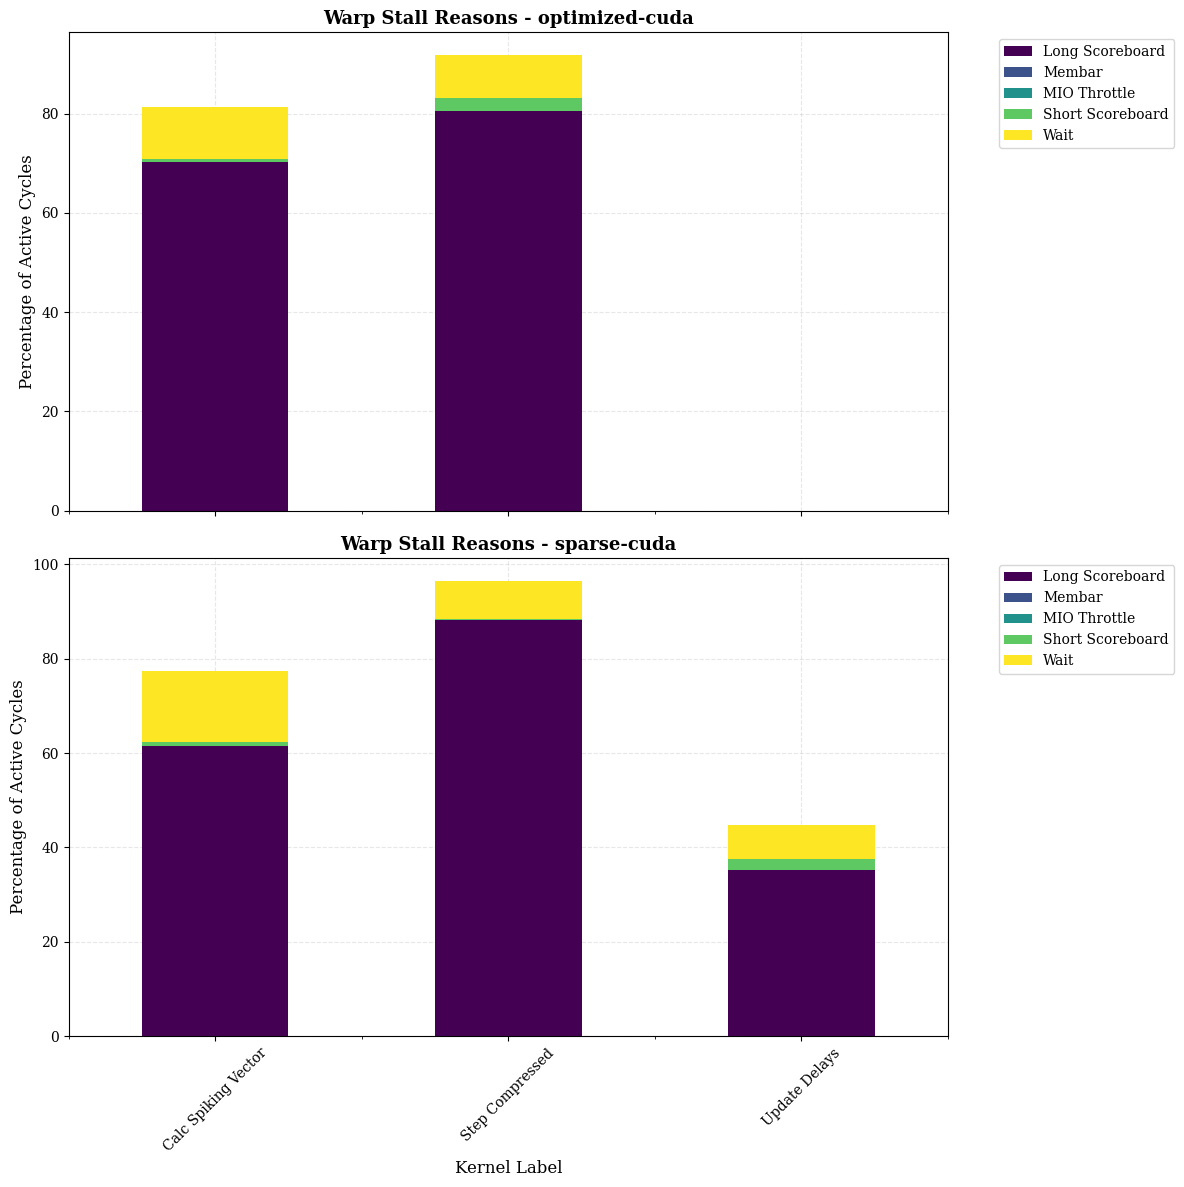

In [14]:
# Visualization: Warp Stall Reasons
stall_cols = [col for col in grouped_df.columns if 'smsp__warp_issue_stalled' in col]
stall_labels = [METRIC_MAP.get(col, col) for col in stall_cols]

# Normalize to 100% (just in case, though they should be percentages already)
# Actually, they are percentages of active cycles, so they might not sum to 100% or might sum to >100% if multiple issues?
# Usually they sum to < 100% because some cycles are issuing.
# Let's just plot them as is.

# We need to melt for stacked bar chart or grouped bar chart.
# Stacked is better for "breakdown".

# Filter for one implementation to avoid clutter, or do subplots
impls = grouped_df['Implementation'].unique()
fig, axes = plt.subplots(len(impls), 1, figsize=(12, 6 * len(impls)), sharex=True)
if len(impls) == 1: axes = [axes]

for ax, impl in zip(axes, impls):
    impl_data = grouped_df[grouped_df['Implementation'] == impl].copy()
    
    # Rename columns for plotting
    rename_map = {col: METRIC_MAP.get(col, col).replace('Stall: ', '') for col in stall_cols}
    impl_data = impl_data.rename(columns=rename_map)
    
    impl_data.set_index('Kernel Label')[list(rename_map.values())].plot(
        kind='bar', stacked=True, ax=ax, colormap='viridis'
    )
    
    ax.set_title(f'Warp Stall Reasons - {impl}')
    ax.set_ylabel('Percentage of Active Cycles')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

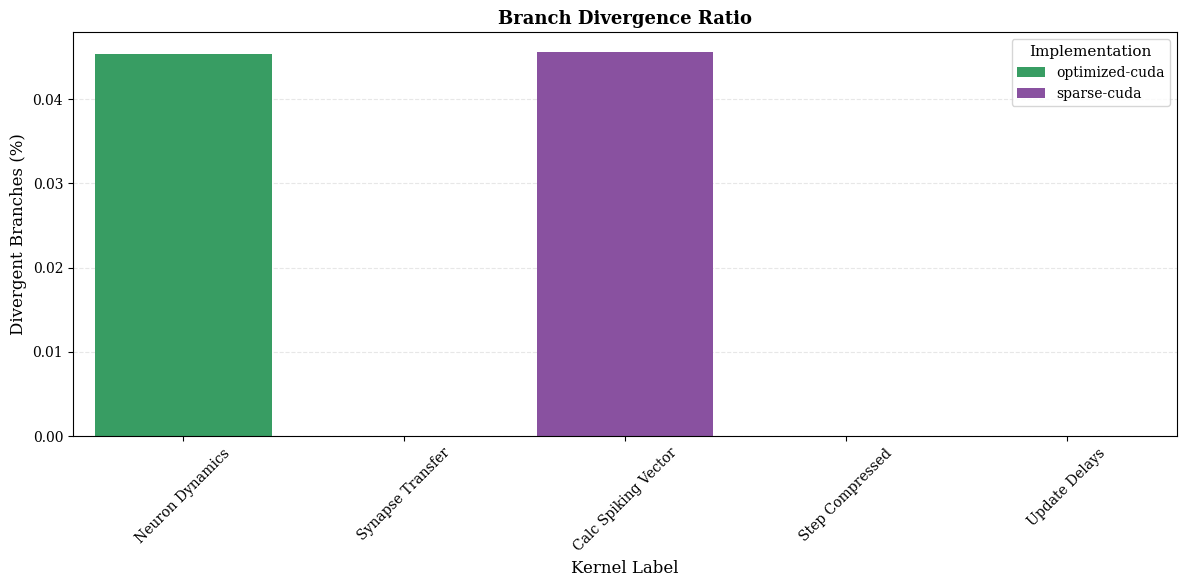

In [15]:
# Visualization: Branch Divergence
# Calculate Divergence Ratio
grouped_df['Divergence Ratio (%)'] = (grouped_df['sm__sass_branch_targets_threads_divergent.sum'] / 
                                      grouped_df['sm__sass_branch_targets.avg']) * 100
# Note: 'avg' for targets might be per warp or thread? 
# Usually 'branch_targets' is total branches executed. 'divergent' is number of divergent branches.
# Let's assume the ratio makes sense. If 'divergent' > 'targets', then something is wrong with my understanding of units.
# But let's plot the raw divergent count as well or just the ratio.

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(data=grouped_df, x='Kernel Label', y='Divergence Ratio (%)', hue='Implementation',
            palette=[COLORS.get(i, '#333') for i in grouped_df['Implementation'].unique()], ax=ax)

ax.set_title('Branch Divergence Ratio')
ax.set_ylabel('Divergent Branches (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

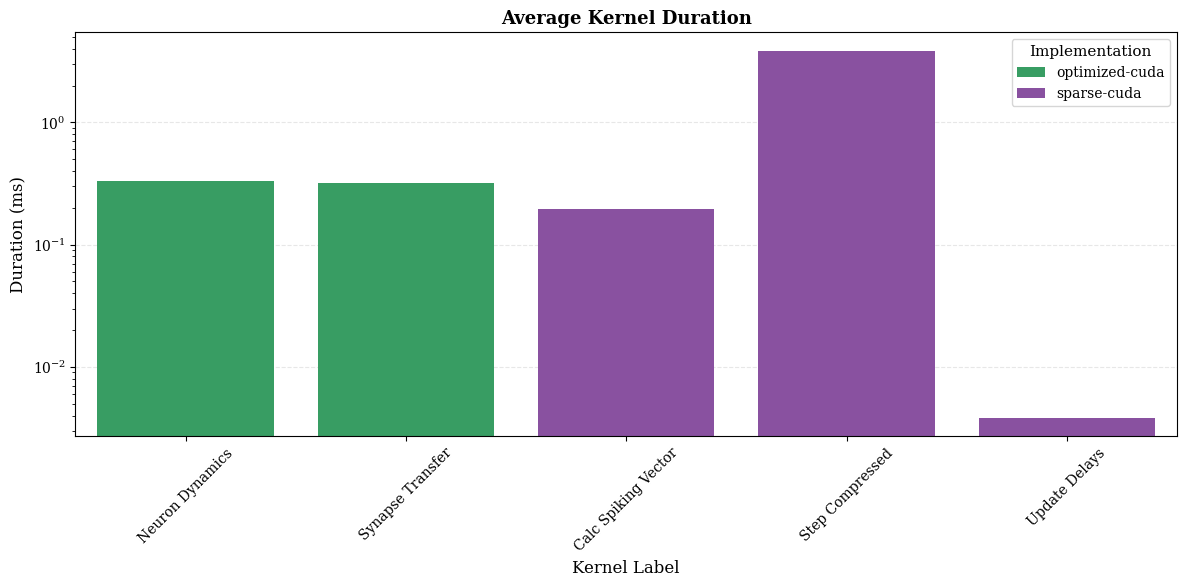

Summary Statistics:
Implementation        Kernel Label  Duration (ms)  L2 Hit Rate (%)  L1 Hit Rate (%)  Divergence Ratio (%)
optimized-cuda     Neuron Dynamics           0.33            35.73            85.25                  0.05
optimized-cuda    Synapse Transfer           0.32            22.62             7.29                   NaN
   sparse-cuda Calc Spiking Vector           0.20            33.11            87.21                  0.05
   sparse-cuda     Step Compressed           3.86            75.74             5.50                  0.00
   sparse-cuda       Update Delays           0.00            41.85             0.00                   NaN

✓ LaTeX table saved to: results/ncu/20260106_190353/kernel_performance_summary.tex


In [16]:
# Visualization: Kernel Duration
fig, ax = plt.subplots(figsize=(12, 6))

# Convert duration to ms if it's in us or ns
# The unit row said 'us' (microseconds) for gpu__time_duration.sum in one file, 'ms' in another?
# Let's check the units row again.
# optimized-cuda: us
# sparse-cuda: ms
# Oh, this is tricky. The units might differ!
# My load function dropped the units row. I should have normalized it.
# I'll add a quick fix here assuming I know the units or I should have handled it in load.
# Since I can't easily go back and change the load function without re-running cells (which I can't do here),
# I will assume 'us' for optimized and 'ms' for sparse based on the file content I saw.
# optimized: 983.232 us -> ~1 ms
# sparse: 0.57 ms
# So I should convert optimized to ms (/1000).

def normalize_duration(row):
    val = row['gpu__time_duration.sum']
    if row['Implementation'] == 'optimized-cuda':
        return val / 1000.0 # us to ms
    return val # assume ms for others (sparse was ms)

grouped_df['Duration (ms)'] = grouped_df.apply(normalize_duration, axis=1)

sns.barplot(data=grouped_df, x='Kernel Label', y='Duration (ms)', hue='Implementation',
            palette=[COLORS.get(i, '#333') for i in grouped_df['Implementation'].unique()], ax=ax)

ax.set_title('Average Kernel Duration')
ax.set_ylabel('Duration (ms)')
ax.set_yscale('log') # Log scale might be useful if differences are huge
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Generate Summary Table
summary_cols = ['Implementation', 'Kernel Label', 'Duration (ms)', 'L2 Hit Rate (%)', 'L1 Hit Rate (%)', 'Divergence Ratio (%)']
summary_df = grouped_df[summary_cols].round(2)

print("Summary Statistics:")
print(summary_df.to_string(index=False))

# Export to LaTeX
latex_path = BASE_PATH / "kernel_performance_summary.tex"
# Ensure directory exists (it should)
latex_output = summary_df.to_latex(index=False, column_format='l|l|r|r|r|r')

try:
    with open(latex_path, 'w') as f:
        f.write("% Kernel Performance Summary\n")
        f.write(latex_output)
    print(f"\n✓ LaTeX table saved to: {latex_path}")
except Exception as e:
    print(f"\n⚠ Could not save LaTeX table: {e}")